In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')

data_folder = Path("../data")
dataset_location = data_folder / "spotify_songs.csv"

# Necessary for notebook to see src
import sys
sys.path.append('..')

from src import tsne_visualization, pca_visualization, DateTimeFeatureExtractor

Device: cuda


In [2]:
original_dataset = pd.read_csv(dataset_location)
dataset = original_dataset.copy(deep=True)

In [3]:
# There is only 5 row that has partial missing values 

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [4]:
# Drop the missing rows

dataset.dropna(inplace=True)

In [5]:
unique_track_ids = dataset['track_id'].unique()

num_of_duplicates = len(dataset) - len(unique_track_ids)
print(f'There is {num_of_duplicates} duplicates present in the dataset')

# Drop the duplicates
dataset.drop_duplicates(subset=['track_id'], keep='first', inplace=True)

There is 4476 duplicates present in the dataset


In [6]:
# DateTime Values

dataset['track_album_release_date'] = pd.to_datetime(dataset['track_album_release_date'])

In [7]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,28352.0,39.335320,23.699443,0.000000,21.00000,42.000000,58.000000,100.000
danceability,28352.0,0.653375,0.145791,0.000000,0.56100,0.670000,0.760000,0.983
energy,28352.0,0.698373,0.183508,0.000175,0.57900,0.722000,0.843000,1.000
key,28352.0,5.367417,3.613743,0.000000,2.00000,6.000000,9.000000,11.000
loudness,28352.0,-6.817777,3.036433,-46.448000,-8.31025,-6.261000,-4.708750,1.275
mode,28352.0,0.565533,0.495696,0.000000,0.00000,1.000000,1.000000,1.000
speechiness,28352.0,0.107939,0.102547,0.000000,0.04100,0.062600,0.133000,0.918
acousticness,28352.0,0.177192,0.222814,0.000000,0.01430,0.079700,0.260000,0.994
instrumentalness,28352.0,0.091129,0.232562,0.000000,0.00000,0.000021,0.006573,0.994
liveness,28352.0,0.190955,0.155888,0.000000,0.09260,0.127000,0.249000,0.996


# Plotting Numerical Values

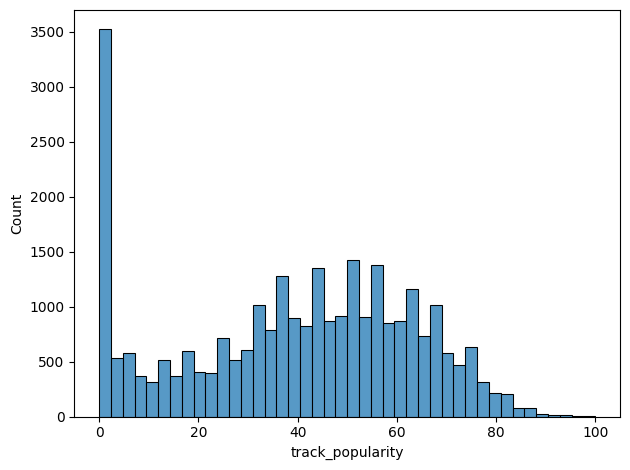

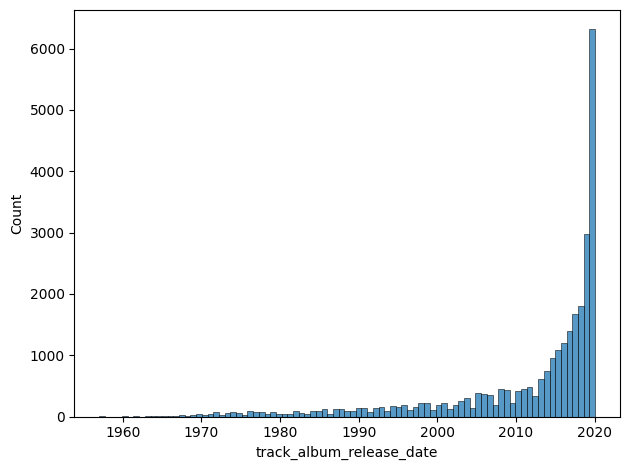

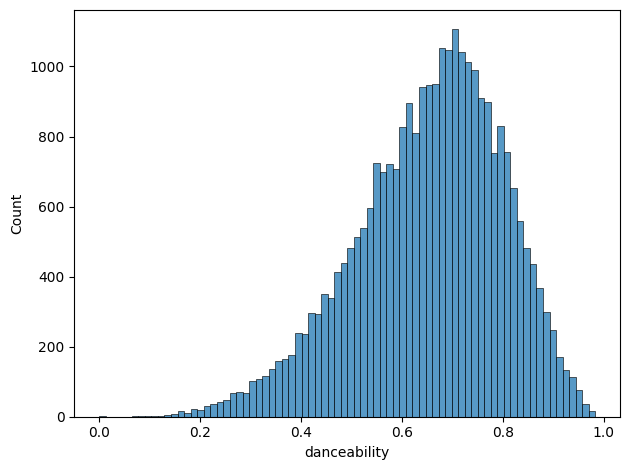

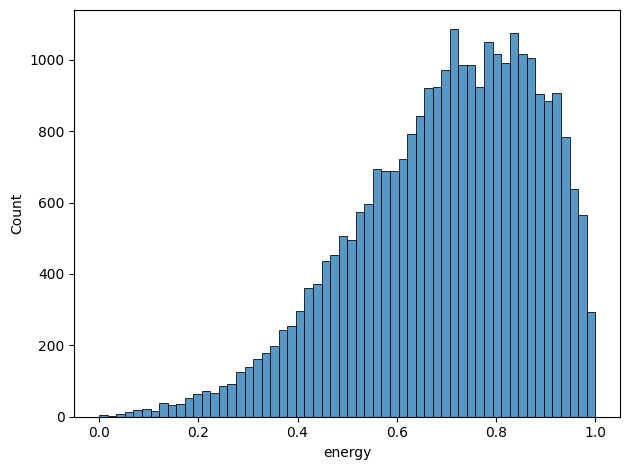

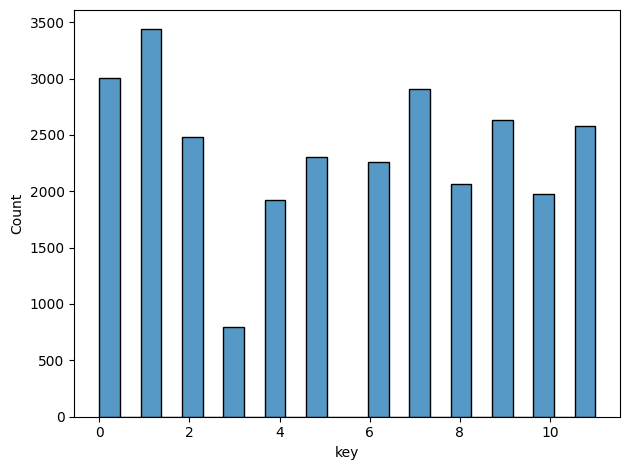

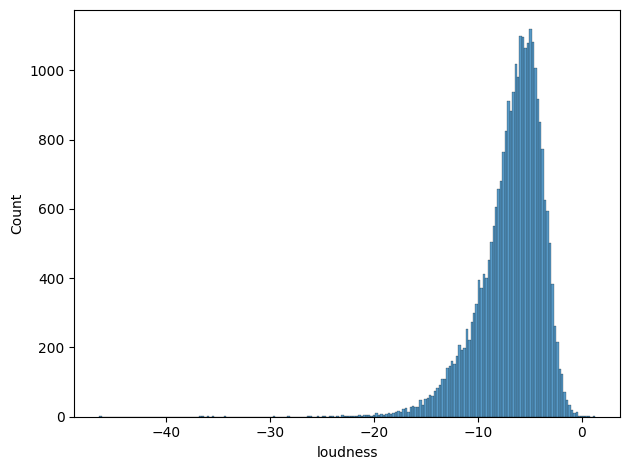

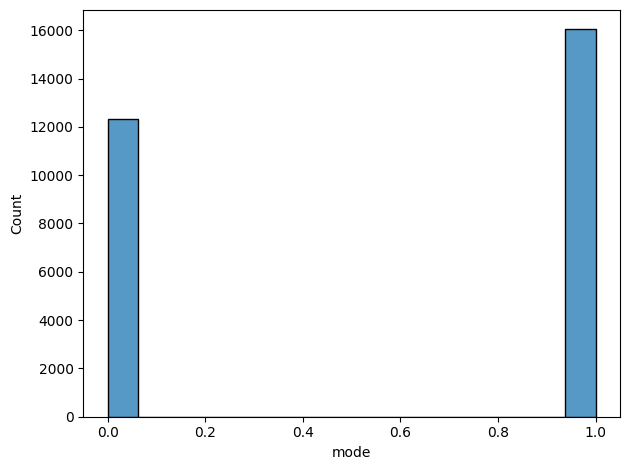

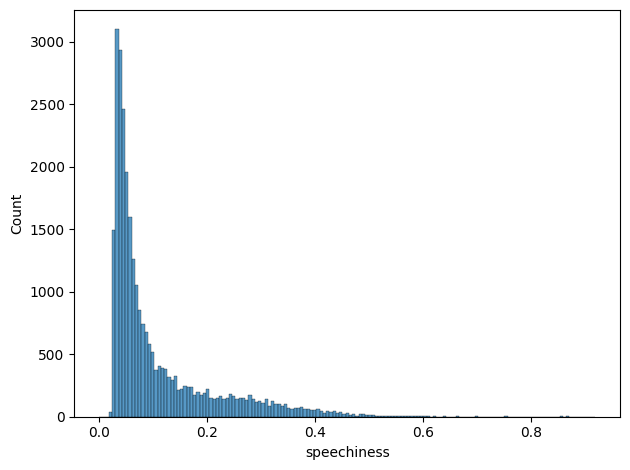

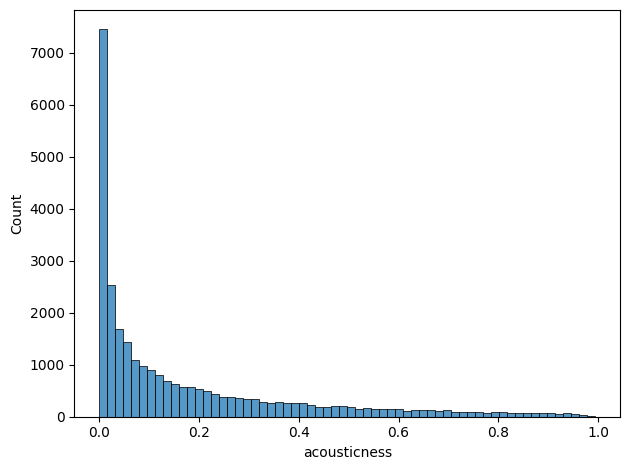

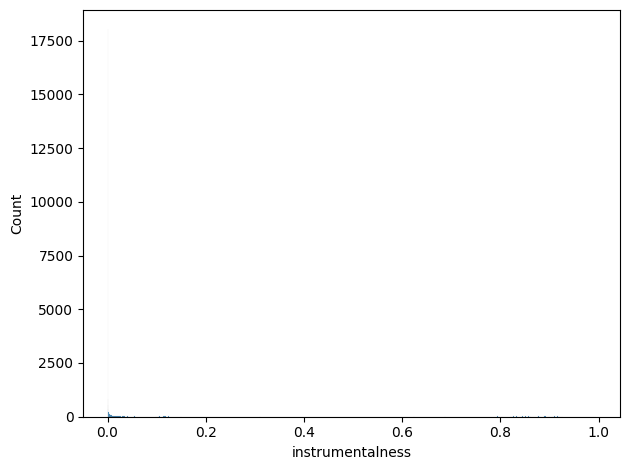

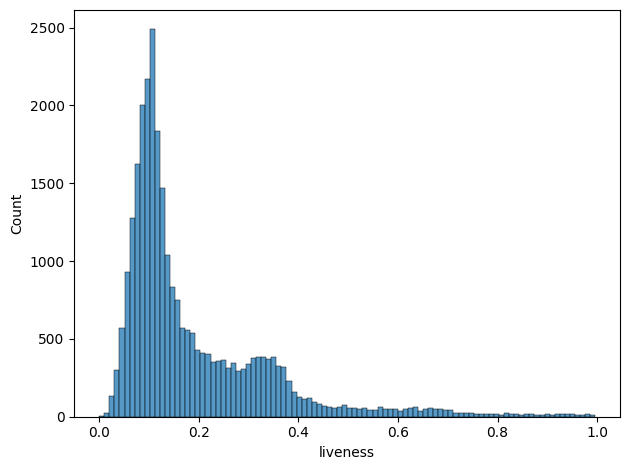

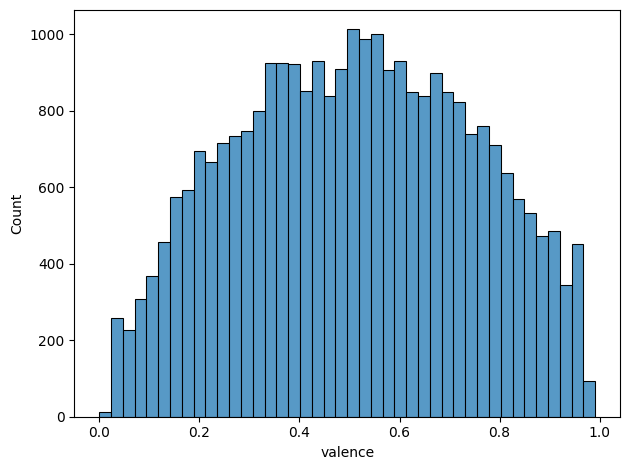

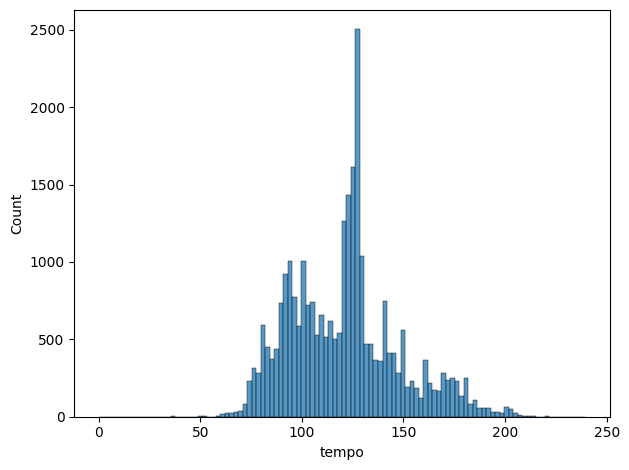

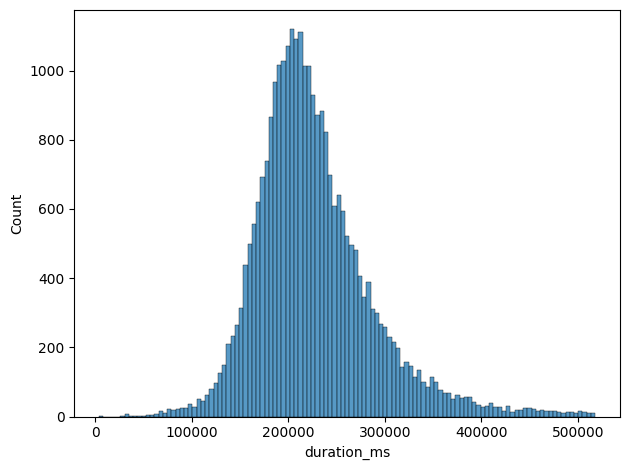

In [8]:
# Mode seems like a discrete feature

number_columns = [col for col in dataset.columns if dataset[col].dtype != "object"] 

for col in number_columns:
    sns.histplot(dataset[col])
    plt.tight_layout()
    plt.show()

# Data Preprocessing

In [9]:
target_col = ['track_popularity']
numeric_cols = [
    col for col in dataset.columns 
    if (dataset[col].dtype != 'object' and col not in ('track_popularity', 'mode', 'track_album_release_date'))
]
string_cols = ['track_artist', 'playlist_id', 'playlist_genre', 'playlist_subgenre']
discrete_cols = ['mode']
datetime_cols = ['track_album_release_date']

In [10]:
# Data Preprocessing

from sklearn.preprocessing import RobustScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


categorical_pipeline = Pipeline(
    steps=[
        ('encoder', OrdinalEncoder(encoded_missing_value=-1))
    ],
)

preprocesser = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline, string_cols),
        ('numerical', FunctionTransformer(lambda x: x), numeric_cols),
        ('datetime', FunctionTransformer(lambda x: x), datetime_cols),
        ('discrete', FunctionTransformer(lambda x: x), discrete_cols),
        ('target', FunctionTransformer(lambda x: x), target_col),
    ],
    sparse_threshold=0,
    remainder='drop',
    verbose_feature_names_out=False,
) 

preprocesser.set_output(transform='pandas')

dataset = preprocesser.fit_transform(dataset)


In [11]:
dataset

,track_artist,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_album_release_date,mode,track_popularity
0,2782.0,234.0,2.0,3.0,0.748,0.916,6,-2.634,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754,2019-06-14,1,66
1,6084.0,234.0,2.0,3.0,0.726,0.815,11,-4.969,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600,2019-12-13,1,67
2,10416.0,234.0,2.0,3.0,0.675,0.931,1,-3.432,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616,2019-07-05,0,70
3,9215.0,234.0,2.0,3.0,0.718,0.930,7,-3.778,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093,2019-07-19,1,60
4,5402.0,234.0,2.0,3.0,0.650,0.833,1,-4.672,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052,2019-03-05,1,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,5725.0,419.0,0.0,18.0,0.428,0.922,2,-1.814,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375,2014-04-28,1,42
32829,9102.0,419.0,0.0,18.0,0.522,0.786,0,-4.462,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120,2013-03-08,1,20
32830,8746.0,419.0,0.0,18.0,0.529,0.821,6,-4.899,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112,2014-04-21,0,14
32831,6140.0,419.0,0.0,18.0,0.626,0.888,2,-3.361,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432,2014-01-01,1,15


# Train Test Split

In [12]:
# This dataset is already limited

X, y = dataset.iloc[:, :-1], dataset['track_popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True) 

train_dataset = pd.concat([X_train, y_train], axis=1)

# GAN Training

In [13]:
from sdv.tabular import CTGAN

ctgan = CTGAN(verbose=True)

ctgan.fit(train_dataset)

/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/rdt/transformers/base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(
/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/rdt/transformers/numerical.py:112: UserWarning: No rounding scheme detected for column 'acousticness'. Data will not be rounded.
  warnings.warn(
/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/rdt/transformers/numerical.py:112: UserWarning: No rounding scheme detected for column 'instrumentalness'. Data will not be rounded.
  warnings.warn(
Gen. (0.00) | Discrim. (0.00):   0%|          | 0/300 [00:00<?, ?it/s]/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Trig

# Visualization

In [14]:
from sklearn.decomposition import PCA

train_len = len(train_dataset)
synthetic_data = ctgan.sample(train_len)

full_dataset = pd.concat([train_dataset, synthetic_data], axis=0)

full_dataset['track_album_release_date'] = full_dataset['track_album_release_date'].astype('int')

scaler = RobustScaler()

full_dataset = scaler.fit_transform(full_dataset)

pca = PCA(n_components=3)

pca_data = pca.fit_transform(full_dataset)

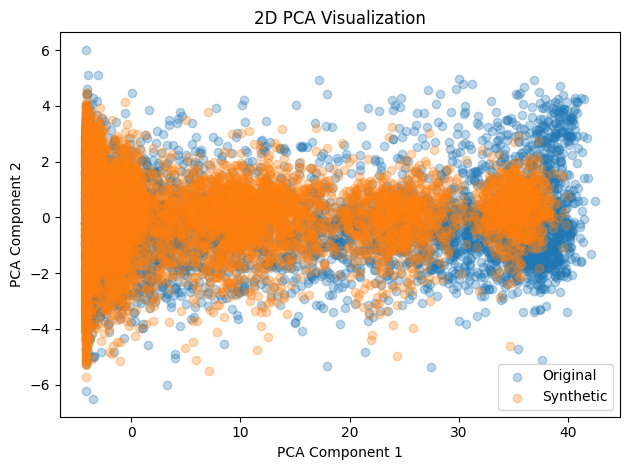

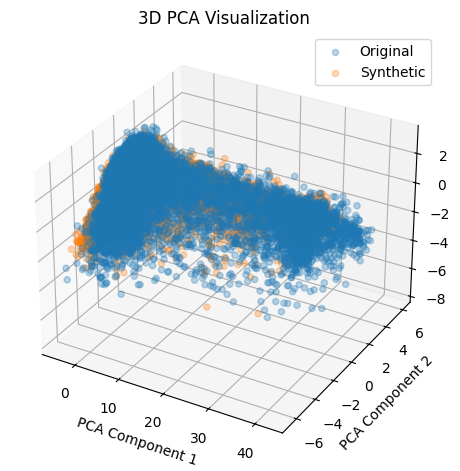

In [15]:
pca_visualization(
    pca_results=[pca_data[:train_len], pca_data[train_len:]],
    labels=['Original', 'Synthetic'],
    alpha=0.3,
    projection_3d=False
)

pca_visualization(
    pca_results=[pca_data[:train_len], pca_data[train_len:]],
    labels=['Original', 'Synthetic'],
    alpha=0.3,
    projection_3d=True
)

In [16]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(full_dataset)

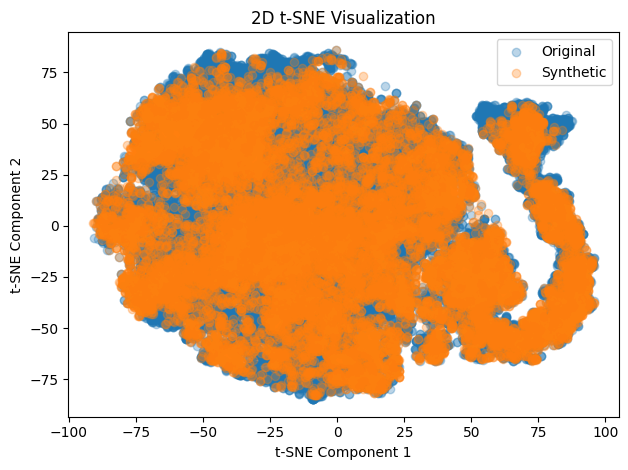

In [17]:
tsne_visualization(
    tsne_results=[tsne_result[:train_len], tsne_result[train_len:]],
    labels=['Original', 'Synthetic'],
    alpha=0.3,
    projection_3d=False
)

# Prediction

In [18]:
# Prediction preprocessing
numerical_pipeline = Pipeline(
    steps=[
        ('scaler', RobustScaler()),
    ],
)

categorical_pipeline = Pipeline(
    steps=[
        ('encoder', FunctionTransformer(lambda x: x)),
    ],
)


extractor =  DateTimeFeatureExtractor()
extractor.set_output(transform='pandas')

datetime_pipeline = Pipeline(
    steps=[
        ('extractor',extractor),
    ],
)

preprocess_transformer = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numeric_cols),
        ('categorical', categorical_pipeline, string_cols),
        ('datetime', datetime_pipeline, datetime_cols),
        ('discrete', FunctionTransformer(lambda x: x), discrete_cols),
    ],
    sparse_threshold=0,
    remainder='drop',
    verbose_feature_names_out=False,
)

y_scaler = RobustScaler()

y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_train = y_train.reshape(-1)

preprocess_transformer.set_output(transform='pandas')

X_train_p = preprocess_transformer.fit_transform(X_train)

In [19]:
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor

regressor = XGBRegressor()

regressor.fit(X_train_p, y_train)
train_predict = regressor.predict(X_train_p)

# Train set Predictions

print('Train Set:')
print(f'Root mean squared error: {root_mean_squared_error(y_train, train_predict)}')
print(f'R2 Score: \t\t {r2_score(y_train, train_predict)}\n')

X_test_p = preprocess_transformer.transform(X_test)
y_test_p = y_scaler.transform(y_test.values.reshape(-1, 1)).reshape(-1)

test_predict = regressor.predict(X_test_p)

print('Test Set:')
print(f'Root mean squared error: {root_mean_squared_error(y_test_p, test_predict)}')
print(f'R2 Score: \t\t {r2_score(y_test_p, test_predict)}')


Train Set:
Root mean squared error: 0.3685100805686754
R2 Score: 		 0.6682880295866858

Test Set:
Root mean squared error: 0.5285343967847868
R2 Score: 		 0.3247897207062397


In [23]:
synthetic_data = ctgan.sample(len(X_train_p))

X_synthetic, y_synhtetic = synthetic_data.iloc[:, :-1], synthetic_data.iloc[:, -1:].values

X_synthetic = preprocess_transformer.transform(X_synthetic)
y_synhtetic = y_scaler.transform(y_synhtetic).reshape(-1)

# Augmentation

X_augmented = pd.concat([X_train_p, X_synthetic], axis=0)
y_augmented = np.concatenate([y_train, y_synhtetic])

regressor.fit(X_augmented, y_augmented)
augmented_predict = regressor.predict(X_augmented)

print('Train Set:')
print(f'Root mean squared error: {root_mean_squared_error(y_augmented, augmented_predict)}')
print(f'R2 Score: \t\t {r2_score(y_augmented, augmented_predict)}\n')

test_predict = regressor.predict(X_test_p)

print('Test Set:')
print(f'Root mean squared error: {root_mean_squared_error(y_test_p, test_predict)}')
print(f'R2 Score: \t\t {r2_score(y_test_p, test_predict)}')


Train Set:
Root mean squared error: 0.467543442079344
R2 Score: 		 0.45232504359840664

Test Set:
Root mean squared error: 0.5484196499692361
R2 Score: 		 0.273026554837946


# GRETEL ACTGAN

In [24]:
from gretel_synthetics.actgan import ACTGAN

actgan = ACTGAN(verbose=True)

actgan.fit(train_dataset)

/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/rdt/transformers/base.py:132: FutureWarning: Future versions of RDT will not support the 'model_missing_values' parameter. Please switch to using the 'missing_value_generation' parameter to select your strategy.
  warnings.warn(
INFO:gretel_synthetics.actgan.actgan_wrapper:Using field types: {}
INFO:gretel_synthetics.actgan.actgan_wrapper:Using field transformers: {}
/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/rdt/transformers/numerical.py:112: UserWarning: No rounding scheme detected for column 'acousticness'. Data will not be rounded.
  warnings.warn(
/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-packages/rdt/transformers/numerical.py:112: UserWarning: No rounding scheme detected for column 'instrumentalness'. Data will not be rounded.
  warnings.warn(
INFO:gretel_synthetics.actgan.data_transformer:Starting data transforms on 18 columns...
/home/tsmn/anaconda3/envs/gan_prj/lib/python3.10/site-pa

# Visualization

In [25]:
train_len = len(train_dataset)
synthetic_data = actgan.sample(train_len)

full_dataset = pd.concat([train_dataset, synthetic_data], axis=0)

full_dataset['track_album_release_date'] = full_dataset['track_album_release_date'].astype('int')

scaler = RobustScaler()

full_dataset = scaler.fit_transform(full_dataset)

pca = PCA(n_components=3)

pca_data = pca.fit_transform(full_dataset)

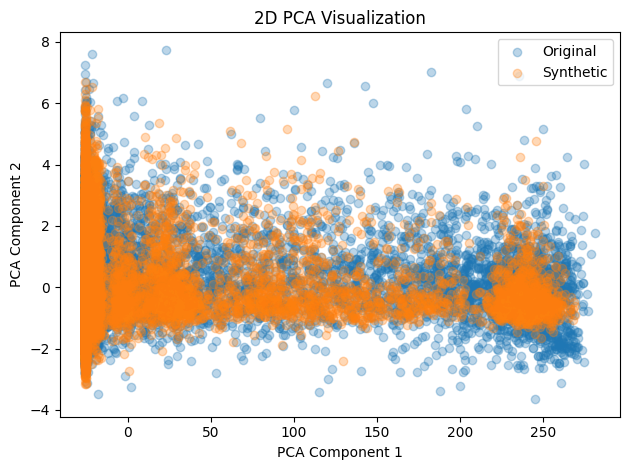

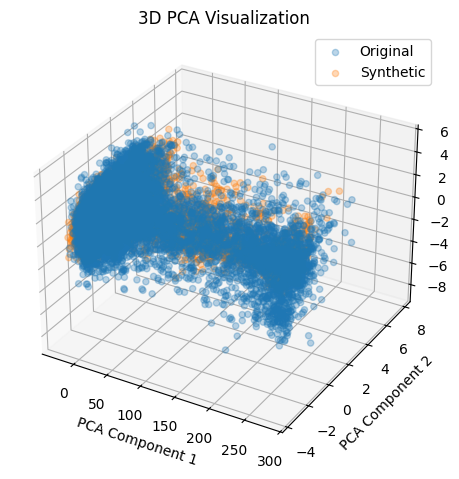

In [26]:
pca_visualization(
    pca_results=[pca_data[:train_len], pca_data[train_len:]],
    labels=['Original', 'Synthetic'],
    alpha=0.3,
    projection_3d=False
)

pca_visualization(
    pca_results=[pca_data[:train_len], pca_data[train_len:]],
    labels=['Original', 'Synthetic'],
    alpha=0.3,
    projection_3d=True
)

In [28]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(full_dataset)

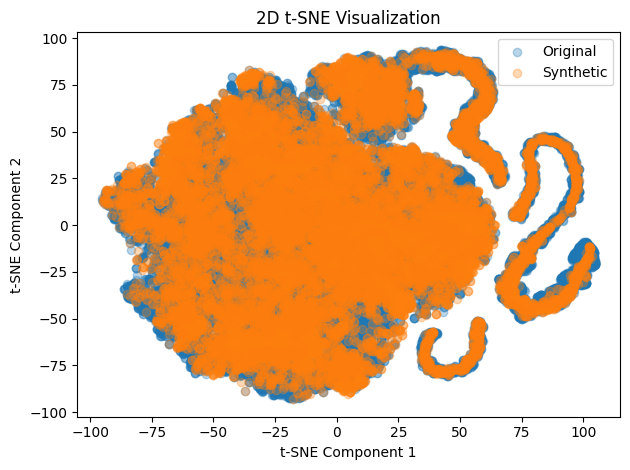

In [29]:
tsne_visualization(
    tsne_results=[tsne_result[:train_len], tsne_result[train_len:]],
    labels=['Original', 'Synthetic'],
    alpha=0.3,
    projection_3d=False
)

In [30]:
synthetic_data = ctgan.sample(len(X_train_p))

X_synthetic, y_synhtetic = synthetic_data.iloc[:, :-1], synthetic_data.iloc[:, -1:].values

X_synthetic = preprocess_transformer.transform(X_synthetic)
y_synhtetic = y_scaler.transform(y_synhtetic).reshape(-1)

# Augmentation

X_augmented = pd.concat([X_train_p, X_synthetic], axis=0)
y_augmented = np.concatenate([y_train, y_synhtetic])

regressor.fit(X_augmented, y_augmented)
augmented_predict = regressor.predict(X_augmented)



print('Train Set:')
print(f'Root mean squared error: {root_mean_squared_error(y_augmented, augmented_predict)}')
print(f'R2 Score: \t\t {r2_score(y_augmented, augmented_predict)}\n')

test_predict = regressor.predict(X_test_p)

print('Test Set:')
print(f'Root mean squared error: {root_mean_squared_error(y_test_p, test_predict)}')
print(f'R2 Score: \t\t {r2_score(y_test_p, test_predict)}')


Train Set:
Root mean squared error: 0.4701970460723883
R2 Score: 		 0.4435013641359191

Test Set:
Root mean squared error: 0.550212386532824
R2 Score: 		 0.26826595948843657
